# Machine Learning 

Plan

1. Import des données (PostgreSQL, avec repli automatique)
	* Importer les données depuis postgres
	* Choisir le grain (churn d'un client et non pas d'un compte )
	* Affichage du dataframe
	* Affichage du type des variables
	* Affichage des valeurs manquantes non tranchées lors de l'ETL (transformer en colonne identifier 	les fuite des signaux métier :  _ missing en plus de l'imputation ou exclure si artefact)
	* Traitement des valeurs manquantes
		* Vérifier la corrélation avec churn
		* Classer en fuite ou signal métier
		* Les signaux métier : imputation et ajouter colonne missing
2. Analyse exploratoire orientée ML
	* Analyse de la distribution de y (comment on va gérer unbalanced data ? quel 	métrique choisir Accuracy)
	* Analyse de la relation entre variable quanti et y 
	* Analyse de la corrélation entre variables (pour éliminer certaines redondance = 	feature selection)
3. Sélection des variables (feature selection)
	Exclure
		* les variables qui sont saisies en post (y) car ne permettent pas de prédire le churn,
		* la Variable (Y)
		* Les variables sans valeur prédictive selon l'expertise métier
		* Les variables à forte cardinalité
		* Les variables quasi constante
4. Séparation X / Y
5. Encodage des variables catégorielles
	* Choisir les variables pour One Hot Encoder et Encodage par fréquence
	* Réaliser que le Hot One encoder avant le split
7. Découpage train/test
	* Encodage par fréquence en post split pour éviter le data leak
6. Mise à l'échelle (scaling)
	* standardiser les variables numériques sur Xtrain seulement (vu en étape 2)
8. Gestion du déséquilibre de classes (SMOTE)
	* Smote sur X_train seulement (on ne touche pas le test)
9. Modèle de référence (régression logistique)
	* entrainement model de ref
	* Matrice de confusion model ref
	* Comparaison métriques model ref
	* Courbe ROC et AUC
10. Tableau comparatif
11. Importance des variables
12. Conclusion

## 1. Import des données

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42  # graine fixe unique pour tout le notebook, voir section 7

In [2]:
def load_from_postgres():
    """Tente de charger les tables nécessaires directement depuis PostgreSQL.

    Retourne un dict {nom_table: DataFrame} en cas de succès, ou None en cas
    d'échec (serveur non démarré, identifiants invalides...) — la fonction
    appelante décide alors de basculer sur le pipeline ETL en mémoire.
    """
    import os
    from sqlalchemy import create_engine

    db_user = os.environ.get("DB_USER", "postgres")
    db_password = os.environ.get("DB_PASSWORD", "postgres")
    db_host = os.environ.get("DB_HOST", "localhost")
    db_port = os.environ.get("DB_PORT", "5432")
    db_name = os.environ.get("DB_NAME", "PIProject")

    connection_string = (
        f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
        f"?client_encoding=utf8"
    )

    try:
        engine = create_engine(connection_string, connect_args={"client_encoding": "utf8"})
        tables = {}
        for table_name in ["fact_account_event", "dim_account", "dim_client", "dim_branch"]:
            tables[table_name] = pd.read_sql_table(table_name, con=engine)
        print("Connexion PostgreSQL réussie — données importées depuis la base.")
        return tables
    except Exception as exc:
        print(f"[INFO] Connexion PostgreSQL impossible ({type(exc).__name__}: {exc}).")
        print("       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).")
        return None


def load_from_etl_pipeline():
    """Repli : reconstruit les mêmes tables via le pipeline ETL en mémoire,
    sans dépendre d'une connexion PostgreSQL. Localise etl_pipeline/ en
    remontant depuis le répertoire courant, comme run.py le fait déjà.
    """
    search_dir = Path.cwd()
    for _ in range(4):
        if (search_dir / "01_etl" / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir / "01_etl"))
            break
        if (search_dir / "etl_pipeline").is_dir():
            sys.path.insert(0, str(search_dir))
            break
        search_dir = search_dir.parent
    else:
        raise ImportError(
            "Impossible de localiser etl_pipeline/ — vérifiez que ce notebook "
            "est bien situé sous 01_etl/notebooks/ ou à la racine du projet."
        )

    from etl_pipeline.pipeline import run_pipeline
    resultats = run_pipeline(load_to_db=False)

    return {
        "fact_account_event": resultats["fact_account_event"],
        "dim_account": resultats["dimensions"]["dim_account"],
        "dim_client": resultats["dimensions"]["dim_client"],
        "dim_branch": resultats["dimensions"]["dim_branch"],
    }


tables = load_from_postgres()
if tables is None:
    tables = load_from_etl_pipeline()

fact_account_event = tables["fact_account_event"]
dim_account = tables["dim_account"]
dim_client = tables["dim_client"]
dim_branch = tables["dim_branch"]

print(f"\nfact_account_event : {fact_account_event.shape}")
print(f"dim_account         : {dim_account.shape}")
print(f"dim_client          : {dim_client.shape}")
print(f"dim_branch          : {dim_branch.shape}")

14:55:21 | INFO     | etl_pipeline.pipeline | ======================================================================
14:55:21 | INFO     | etl_pipeline.pipeline | DÉBUT DU PIPELINE ETL
14:55:21 | INFO     | etl_pipeline.pipeline | ======================================================================
14:55:21 | INFO     | etl_pipeline.pipeline | --- ÉTAPE 1/5 : EXTRACT ---


[INFO] Connexion PostgreSQL impossible (ValueError: Table fact_account_event not found).
       Bascule sur le pipeline ETL en mémoire (etl_pipeline.pipeline).


14:55:23 | INFO     | etl_pipeline.extract | Extraction terminée : 528,883 lignes, 34 colonnes
14:55:23 | WARNING  | etl_pipeline.extract | Dimension 'category_account' introuvable (C:\Users\HP\OneDrive\Bureau\ESB\ML\Mon_projet_git\ProjetIntegre_Churn_HAFAS\data\dim_CATEGORY_ACCOUNT.xlsx) — ignorée.
14:55:23 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'currency' : Excel file format cannot be determined, you must specify an engine manually.
14:55:23 | WARNING  | etl_pipeline.extract | Dimension 'closure_reason' introuvable (C:\Users\HP\OneDrive\Bureau\ESB\ML\Mon_projet_git\ProjetIntegre_Churn_HAFAS\data\dim_Closure_reason.xlsx) — ignorée.
14:55:23 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'dao' : Excel file format cannot be determined, you must specify an engine manually.
14:55:23 | WARNING  | etl_pipeline.extract | Échec de lecture de la dimension 'industry' : Excel file format cannot be determined, you must specify an engine manually


fact_account_event : (445803, 14)
dim_account         : (410587, 11)
dim_client          : (319129, 15)
dim_branch          : (141, 6)


### Construction du jeu de données au grain client

`fact_account_event` est au grain **événement**, On agrège donc d'abord au grain **Client** 

Group BY

In [3]:
agg_fact = fact_account_event.groupby("client_key").agg(
    acct_balance=("acct_balance", "mean"),
    salary=("salary", "mean"),
    amount_total=("amount", "sum"),
    fixedrate_mean=("fixedrate", "mean"),
    nb_produits=("product_key", "count"),
    nb_comptes=("account_key", "nunique"),       # nombre de comptes distincts
    churn=("churn", "min"),   # min : 1 seulement si tous les comptes sont fermés
).reset_index()
 
df_ml = agg_fact  

In [4]:
print(dim_client.columns.tolist())

['client_key', 'CUSTOMER_NO', 'DATE_OF_BIRTH', 'age', 'MARITAL_STATUS', 'NATIONALITY', 'RESIDENCE', 'NATURE_CLIENT', 'PARTYCLASS', 'LOB', 'INDUSTRY', 'SCORE_KYC', 'COMPLETED_FILE', 'CUST_OPENING_DATE', 'LAST_REVIEW_DATE']


Jointure avec dim Branch : Branch (dominante) et dim client : industry

In [5]:
df_ml = df_ml.merge(
    dim_client[["client_key", "age", "MARITAL_STATUS", "NATIONALITY", "RESIDENCE",
                "NATURE_CLIENT", "PARTYCLASS", "LOB", "INDUSTRY", "SCORE_KYC",
                "COMPLETED_FILE"]],
    on="client_key", how="left"
)
branch_dominante = (
    fact_account_event.groupby("client_key")["branch_key"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
)
# 3. Merge de la branch dominante dans df_ml 
df_ml = df_ml.merge(branch_dominante, on="client_key", how="left")

# 4. Jointure avec dim_branch pour récupérer le libellé BRANCH
df_ml = df_ml.merge(
    dim_branch[["branch_key", "BRANCH"]],
    on="branch_key", how="left"
)
df_ml = df_ml.drop(columns=["branch_key"])

### Aperçu de la structure du jeu de données

In [6]:
pd.set_option('display.max_columns', None)
df_ml.head()

,client_key,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,nb_comptes,churn,age,MARITAL_STATUS,NATIONALITY,RESIDENCE,NATURE_CLIENT,PARTYCLASS,LOB,INDUSTRY,SCORE_KYC,COMPLETED_FILE,BRANCH
0,CLI_000001,NaN,400.0,0.000,0.0,1,1,1,43,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR77
1,CLI_000002,NaN,400.0,0.000,0.0,1,1,1,61,C,TN,TN,PPH,Retail,4,9000,H1,NO,BR96
2,CLI_000003,282.9330,400.0,282.933,0.0,1,1,0,34,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95
3,CLI_000004,282.9330,400.0,282.933,0.0,1,1,0,31,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95
4,CLI_000005,-9535.3445,NaN,-38141.378,0.0,4,4,0,48,NON_APPLICABLE,TN,TN,PM,Corporate Small,11,4774,MR,NO,BR77


In [7]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319129 entries, 0 to 319128
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   client_key      319129 non-null  object 
 1   acct_balance    224573 non-null  float64
 2   salary          137870 non-null  float64
 3   amount_total    319129 non-null  float64
 4   fixedrate_mean  319129 non-null  float64
 5   nb_produits     319129 non-null  int64  
 6   nb_comptes      319129 non-null  int64  
 7   churn           319129 non-null  int64  
 8   age             319129 non-null  int32  
 9   MARITAL_STATUS  319129 non-null  object 
 10  NATIONALITY     319129 non-null  object 
 11  RESIDENCE       319129 non-null  object 
 12  NATURE_CLIENT   319129 non-null  object 
 13  PARTYCLASS      319129 non-null  object 
 14  LOB             319129 non-null  int64  
 15  INDUSTRY        319129 non-null  object 
 16  SCORE_KYC       319129 non-null  object 
 17  COMPLETED_

In [8]:
df_ml.describe()

,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,nb_comptes,churn,age,LOB
count,2.245730e+05,1.378700e+05,3.191290e+05,319129.000000,319129.000000,319129.000000,319129.000000,319129.000000,319129.000000
mean,4.917622e+03,1.639442e+03,1.729036e+07,0.542142,1.396937,1.286586,0.367745,47.616268,4.605780
std,1.261281e+05,1.964418e+04,1.009957e+09,2.109037,5.968056,1.169316,0.482192,16.360478,2.790298
min,-2.719533e+07,0.000000e+00,-1.375421e+07,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,5.100000e-01,4.000000e+02,0.000000e+00,0.000000,1.000000,1.000000,0.000000,36.000000,4.000000
50%,6.838000e+01,6.000000e+02,4.824000e+00,0.000000,1.000000,1.000000,0.000000,48.000000,4.000000
75%,2.857713e+03,1.200000e+03,2.543618e+03,0.000000,1.000000,1.000000,1.000000,59.000000,4.000000
max,1.060413e+07,1.098636e+06,3.264058e+11,13.080000,1659.000000,92.000000,1.000000,100.000000,999.000000


### Valeurs manquantes et types de données

Selon notre pipeline ETL (**acct_balance**, **salary**)

In [9]:
missing = df_ml.isna().sum()
missing_pct = (missing / len(df_ml) * 100).round(2)
missing_df = pd.DataFrame({"Manquant": missing, "%": missing_pct})
missing_df = missing_df[missing_df["Manquant"] > 0].sort_values("%", ascending=False)
print("Colonnes avec valeurs manquantes :")
missing_df

Colonnes avec valeurs manquantes :


,Manquant,%
salary,181259,56.80
acct_balance,94556,29.63


Traitement des valeurs manquantes résiduelles
**Ajouter une colonne salary_missing** + 
**Imputation retenue : la médiane** pas la moyenne skew élevé sur salary/Acct_balance

In [10]:
#Ajouter une colonne "Salary_missing"
df_ml["salary_missing"] = df_ml["salary"].isna().astype(int)

print(df_ml.groupby("salary_missing")["churn"].mean() * 100)

salary_missing
0    35.574817
1    37.686956
Name: churn, dtype: float64


In [11]:
# Imputation du salaire par la médiane 
df_ml["salary"] = df_ml["salary"].fillna(df_ml["salary"].median())

Vérification du data leakage de acct_balance

In [12]:
def taux_churn_par_manquant(df, colonne, cible="churn"):
    """
    Compare le taux de churn selon que la colonne est manquante ou non.
    Sert à détecter un data leakage potentiel.
    """
    mask_manquant = df[colonne].isna()
    
    n_manquant = mask_manquant.sum()
    n_renseigne = (~mask_manquant).sum()
    
    taux_si_manquant = df.loc[mask_manquant, cible].mean() * 100
    taux_si_renseigne = df.loc[~mask_manquant, cible].mean() * 100
    
    print(f"{colonne:20s} : {n_manquant:,} manquants | "
          f"taux churn si manquant = {taux_si_manquant:5.1f}% | "
          f"si renseigné = {taux_si_renseigne:5.1f}%")

In [13]:
taux_churn_par_manquant(df_ml, "acct_balance")

acct_balance         : 94,556 manquants | taux churn si manquant = 100.0% | si renseigné =  10.2%


Risque de data leakage : on n'impute pas les valeurs manquantes

In [14]:
pd.set_option('display.max_columns', None)
df_ml.head()

,client_key,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,nb_comptes,churn,age,MARITAL_STATUS,NATIONALITY,RESIDENCE,NATURE_CLIENT,PARTYCLASS,LOB,INDUSTRY,SCORE_KYC,COMPLETED_FILE,BRANCH,salary_missing
0,CLI_000001,NaN,400.0,0.000,0.0,1,1,1,43,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR77,0
1,CLI_000002,NaN,400.0,0.000,0.0,1,1,1,61,C,TN,TN,PPH,Retail,4,9000,H1,NO,BR96,0
2,CLI_000003,282.9330,400.0,282.933,0.0,1,1,0,34,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95,0
3,CLI_000004,282.9330,400.0,282.933,0.0,1,1,0,31,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95,0
4,CLI_000005,-9535.3445,600.0,-38141.378,0.0,4,4,0,48,NON_APPLICABLE,TN,TN,PM,Corporate Small,11,4774,MR,NO,BR77,1


## 2. Analyse exploratoire orientée Machine Learning


### 2.1 Distribution de la variable cible (churn)


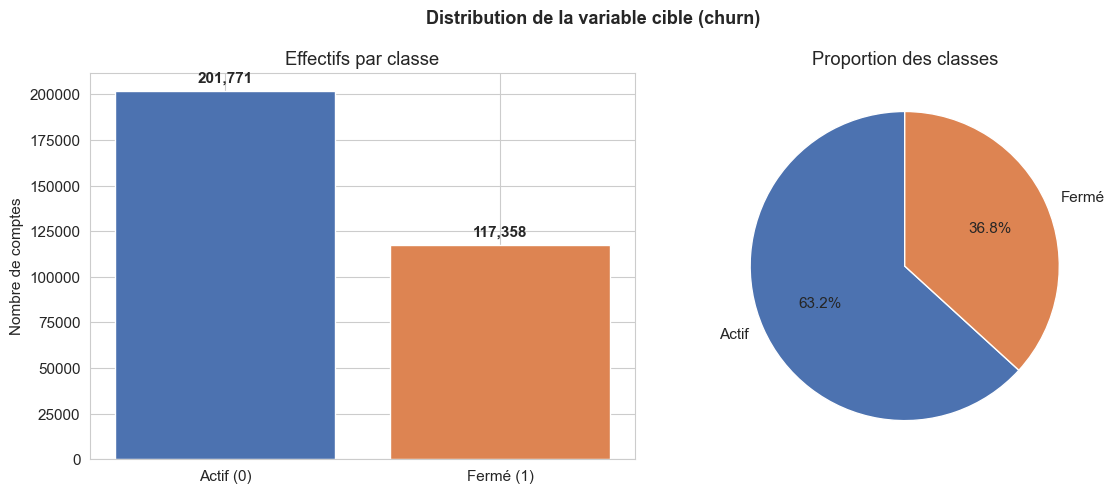

Ratio déséquilibre (majoritaire / minoritaire) : 1.72 : 1


In [15]:
churn_counts = df_ml["churn"].value_counts().sort_index()
churn_pct = df_ml["churn"].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Actif (0)", "Fermé (1)"], churn_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Effectifs par classe")
axes[0].set_ylabel("Nombre de comptes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(churn_pct.values, labels=["Actif", "Fermé"], autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Proportion des classes")

plt.suptitle("Distribution de la variable cible (churn)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Ratio déséquilibre (majoritaire / minoritaire) : "
      f"{churn_counts.max() / churn_counts.min():.2f} : 1")

**Interprétation** : la classe minoritaire (**churn = 1**, client qui a quitté = fermé tous ces comptes) représente
environ 36% du jeu de données = un déséquilibre **modéré**

transformer LOB et industry en str

In [16]:
df_ml["LOB"] = df_ml["LOB"].astype(str)
df_ml["INDUSTRY"] = df_ml["INDUSTRY"].astype(str)

In [17]:
num_features = ["salary", "amount_total", "fixedrate_mean", "nb_produits", "nb_comptes", "age"]

### 2.3 Matrice de corrélation

Utile pour la feature selection

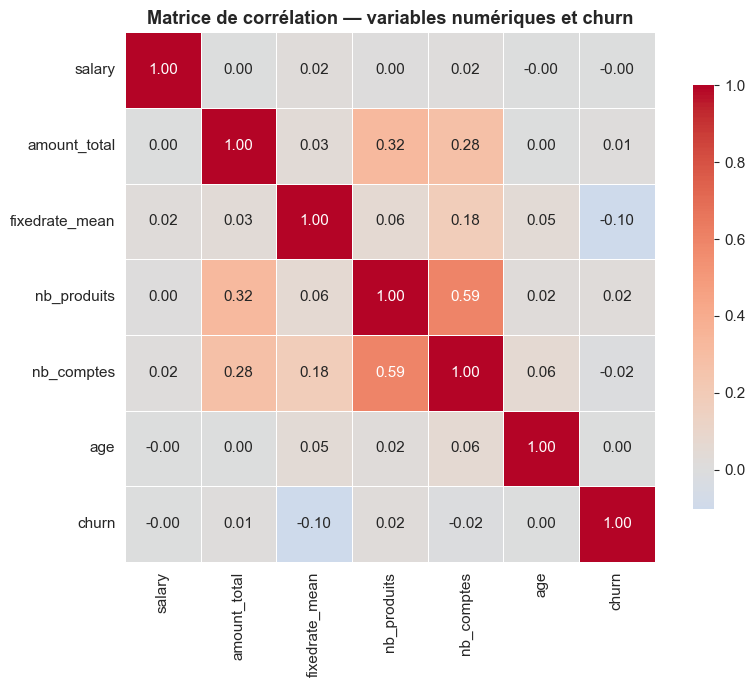

In [18]:
corr_cols = num_features + ["churn"]
corr_matrix = df_ml[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation — variables numériques et churn", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# Est-ce que nb_produits == nb_comptes pour (presque) tous les clients ?
print((df_ml["nb_produits"] == df_ml["nb_comptes"]).mean())

# Regarde la distribution des écarts
print((df_ml["nb_produits"] - df_ml["nb_comptes"]).describe())

0.9909629021492876
count    319129.00000
mean          0.11035
std           5.35842
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max        1580.00000
dtype: float64


In [20]:
df_ml.head()

,client_key,acct_balance,salary,amount_total,fixedrate_mean,nb_produits,nb_comptes,churn,age,MARITAL_STATUS,NATIONALITY,RESIDENCE,NATURE_CLIENT,PARTYCLASS,LOB,INDUSTRY,SCORE_KYC,COMPLETED_FILE,BRANCH,salary_missing
0,CLI_000001,NaN,400.0,0.000,0.0,1,1,1,43,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR77,0
1,CLI_000002,NaN,400.0,0.000,0.0,1,1,1,61,C,TN,TN,PPH,Retail,4,9000,H1,NO,BR96,0
2,CLI_000003,282.9330,400.0,282.933,0.0,1,1,0,34,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95,0
3,CLI_000004,282.9330,400.0,282.933,0.0,1,1,0,31,C,TN,TN,PPH,Retail,4,9000,LR,NO,BR95,0
4,CLI_000005,-9535.3445,600.0,-38141.378,0.0,4,4,0,48,NON_APPLICABLE,TN,TN,PM,Corporate Small,11,4774,MR,NO,BR77,1


 Vérification si data leakage pour completed_file tableau de contingence (completed_file et churn)

In [21]:
print(df_ml.groupby("COMPLETED_FILE")["churn"].mean() * 100)
print(df_ml["COMPLETED_FILE"].value_counts())

COMPLETED_FILE
NO     49.575813
YES    22.486357
Name: churn, dtype: float64
COMPLETED_FILE
NO     168322
YES    150807
Name: count, dtype: int64


3. Sélection des variables (Feature Selection)
Variables exclues :

* acct_balance — fuite d'information (100% churn si manquant)
* client_key — identifiant sans valeur prédictive
* nb_comptes — redondante avec nb_produits (99,1% de correspondance)
* NATIONALITY, RESIDENCE — quasi-constantes (majoritairement 'TN')

Variables conservées :

* Numériques : salary, amount_total, fixedrate_mean, age, nb_produits
* Catégorielles : MARITAL_STATUS, NATURE_CLIENT, PARTYCLASS, LOB, INDUSTRY, SCORE_KYC, COMPLETED_FILE, BRANCH

In [22]:
# Colonnes explicitement exclues, avec leur raison (pour traçabilité dans le notebook)
colonnes_exclues = {
    "client_key": "identifiant",
    "acct_balance": "fuite d'information (100% churn si manquant)",
    "nb_comptes": "redondant avec nb_produits (99,1% de correspondance)",
    "NATIONALITY": "quasi-constante (majoritairement 'TN')",
    "RESIDENCE": "quasi-constante (majoritairement 'TN')",
}

features_numeriques = ["salary", "amount_total", "fixedrate_mean", "nb_produits", "age","salary_missing"]

features_categorielles = [
    "MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS",
    "LOB", "INDUSTRY", "SCORE_KYC", "COMPLETED_FILE","BRANCH"
]

print(f"Variables numériques retenues   ({len(features_numeriques)}) : {features_numeriques}")
print(f"Variables catégorielles retenues ({len(features_categorielles)}) : {features_categorielles}")
print(f"\nCardinalité des variables catégorielles :")
for col in features_categorielles:
    print(f"  {col:20s} : {df_ml[col].nunique()} valeurs uniques")

Variables numériques retenues   (6) : ['salary', 'amount_total', 'fixedrate_mean', 'nb_produits', 'age', 'salary_missing']
Variables catégorielles retenues (8) : ['MARITAL_STATUS', 'NATURE_CLIENT', 'PARTYCLASS', 'LOB', 'INDUSTRY', 'SCORE_KYC', 'COMPLETED_FILE', 'BRANCH']

Cardinalité des variables catégorielles :
  MARITAL_STATUS       : 6 valeurs uniques
  NATURE_CLIENT        : 6 valeurs uniques
  PARTYCLASS           : 5 valeurs uniques
  LOB                  : 9 valeurs uniques
  INDUSTRY             : 637 valeurs uniques
  SCORE_KYC            : 5 valeurs uniques
  COMPLETED_FILE       : 2 valeurs uniques
  BRANCH               : 141 valeurs uniques


## 3. Séparation Features (X) et Cible (y)

In [23]:
y = df_ml["churn"].copy()
X = df_ml[features_numeriques + features_categorielles].copy()

print(f"X : {X.shape[0]:,} lignes x {X.shape[1]} colonnes")
print(f"y : {y.shape[0]:,} valeurs, taux de churn = {y.mean()*100:.1f}%")
X.head()

X : 319,129 lignes x 14 colonnes
y : 319,129 valeurs, taux de churn = 36.8%


,salary,amount_total,fixedrate_mean,nb_produits,age,salary_missing,MARITAL_STATUS,NATURE_CLIENT,PARTYCLASS,LOB,INDUSTRY,SCORE_KYC,COMPLETED_FILE,BRANCH
0,400.0,0.000,0.0,1,43,0,C,PPH,Retail,4,9000,LR,NO,BR77
1,400.0,0.000,0.0,1,61,0,C,PPH,Retail,4,9000,H1,NO,BR96
2,400.0,282.933,0.0,1,34,0,C,PPH,Retail,4,9000,LR,NO,BR95
3,400.0,282.933,0.0,1,31,0,C,PPH,Retail,4,9000,LR,NO,BR95
4,600.0,-38141.378,0.0,4,48,1,NON_APPLICABLE,PM,Corporate Small,11,4774,MR,NO,BR77


## 4. Encodage des variables catégorielles
* One hot encoder avant le Split 
* Encodage par fréquence *aprés le Split*

In [24]:
features_onehot = ["MARITAL_STATUS", "NATURE_CLIENT", "PARTYCLASS", "SCORE_KYC",
                    "COMPLETED_FILE", "LOB"]
features_frequence = ["BRANCH","INDUSTRY"]

print("Cardinalité des variables encodées en One-Hot :")
for col in features_onehot:
    print(f"  {col:18s} : {X[col].nunique()} catégories")
print("\nCardinalité des variables encodées par fréquence :")
for col in features_frequence:
    print(f"  {col:18s} : {X[col].nunique()} catégories")

Cardinalité des variables encodées en One-Hot :
  MARITAL_STATUS     : 6 catégories
  NATURE_CLIENT      : 6 catégories
  PARTYCLASS         : 5 catégories
  SCORE_KYC          : 5 catégories
  COMPLETED_FILE     : 2 catégories
  LOB                : 9 catégories

Cardinalité des variables encodées par fréquence :
  BRANCH             : 141 catégories
  INDUSTRY           : 637 catégories


In [70]:
X_encoded = pd.get_dummies(X, columns=features_onehot, drop_first=True)

print(f"X avant encodage     : {X.shape[1]} colonnes")
print(f"X après One-Hot       : {X_encoded.shape[1]} colonnes")
print(f"(BRANCH reste à encoder par fréquence après le split)")

X avant encodage     : 14 colonnes
X après One-Hot       : 35 colonnes
(BRANCH reste à encoder par fréquence après le split)


In [71]:
joblib.dump(X_encoded.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

## 5. Découpage Train / Test

Ratio retenu : 80% / 20%

Stratification

`stratify=y` garantit que la proportion de comptes fermés est **identique** dans le
train et le test (≈36,1% dans les deux) 

Graine aléatoire fixe

`random_state=42`  garantit que ce notebook produit **exactement les mêmes**
résultats à chaque exécution, condition nécessaire à la reproductibilité demandée.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]:,} Clients ({X_train.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} Clients ({X_test.shape[0]/len(X_encoded)*100:.0f}%)")
print(f"\nTaux de churn train : {y_train.mean()*100:.2f}%")
print(f"Taux de churn test  : {y_test.mean()*100:.2f}%")

Train : 255,303 Clients (80%)
Test  : 63,826 Clients (20%)

Taux de churn train : 36.77%
Taux de churn test  : 36.77%


### Encodage par fréquence — ajusté uniquement sur le train

In [66]:
frequency_encoders = {}

for col in features_frequence:
    freq_map = X_train[col].value_counts(normalize=True)

    frequency_encoders[col] = freq_map.to_dict()

    X_train[col] = X_train[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map).fillna(0)

import joblib
joblib.dump(frequency_encoders, "frequency_encoder.pkl")

['frequency_encoder.pkl']

In [67]:
# Sauvegarde des dictionnaires
joblib.dump(frequency_encoders, "frequency_encoder.pkl")

['frequency_encoder.pkl']

## 6. Standardisation

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print("Mise à l'échelle effectuée (ajustée sur X_train, appliquée à X_test).")
print("\nMoyenne après standardisation (train) :", X_train_scaled.mean().mean().round(4))
print("Écart-type après standardisation (train) :", X_train_scaled.std().mean().round(4))

Mise à l'échelle effectuée (ajustée sur X_train, appliquée à X_test).

Moyenne après standardisation (train) : 0.0
Écart-type après standardisation (train) : 1.0


In [63]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## 7. Gestion du déséquilibre de classes


### SMOTE (Synthetic Minority Over-sampling Technique)


*Nb : SMOTE s'applique uniquement sur le jeu d'entraînement (X_Train , y_train), jamais sur le jeu de test*

In [29]:
# Demonstration concrete du piege de l'accuracy : un modele "naif" qui predit
# toujours la classe majoritaire.
from sklearn.metrics import accuracy_score

y_pred_naif = np.zeros(len(y_test))  # toujours "actif"
accuracy_naive = accuracy_score(y_test, y_pred_naif)
print(f"Accuracy d'un modèle qui prédit toujours 'Actif' : {accuracy_naive*100:.1f}%")
print("-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte "
      "à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.")

Accuracy d'un modèle qui prédit toujours 'Actif' : 63.2%
-> Ce chiffre est trompeusement élevé : ce modèle ne détecte JAMAIS un compte à risque de fermeture, il n'a aucune utilité métier malgré une accuracy correcte.


In [32]:
from imblearn.over_sampling import SMOTE

print(f"Avant SMOTE — train : {len(y_train):,} lignes, "
      f"{y_train.sum():,} fermés ({y_train.mean()*100:.1f}%)")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Après SMOTE — train  : {len(y_train_smote):,} lignes, "
      f"{y_train_smote.sum():,} fermés ({y_train_smote.mean()*100:.1f}%)")
print(f"\nJeu de test inchangé : {len(y_test):,} lignes, "
      f"taux de churn réel = {y_test.mean()*100:.1f}% (NE DOIT PAS être modifié par SMOTE).")

Avant SMOTE — train : 255,303 lignes, 93,886 fermés (36.8%)
Après SMOTE — train  : 322,834 lignes, 161,417 fermés (50.0%)

Jeu de test inchangé : 63,826 lignes, taux de churn réel = 36.8% (NE DOIT PAS être modifié par SMOTE).


Les deux jeux d'entraînement (`X_train_scaled`/`y_train` sans rééquilibrage, et
`X_train_smote`/`y_train_smote` rééquilibré) sont conservés en parallèle — chaque
modèle de la section 10 sera entraîné sur les deux versions pour mesurer concrètement
l'effet de SMOTE, comme demandé.

## 8. Modèle de référence (Baseline) : Régression Logistique


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay,
)
import time

log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

debut = time.time()
log_reg.fit(X_train_scaled, y_train)
temps_entrainement = time.time() - debut

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Régression logistique entraînée en {temps_entrainement:.2f} secondes.")

Régression logistique entraînée en 0.69 secondes.


### Métriques d'évaluation 

$$\text{Precision} = \frac{TP}{TP + FP} \qquad
\text{Recall} = \frac{TP}{TP + FN} \qquad
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [ ]:
def afficher_metriques(y_true, y_pred, y_proba, nom_modele):
    """Calcule et affiche les métriques standard pour un modèle donné."""
    metrics = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }
    print(f"--- {nom_modele} ---")
    for k, v in metrics.items():
        if k != "Modèle":
            print(f"  {k:12s} : {v:.4f}")
    return metrics


metrics_log_reg = afficher_metriques(y_test, y_pred, y_proba, "Régression Logistique (baseline)")

--- Régression Logistique (baseline) ---
  Accuracy     : 0.6836
  Precision    : 0.5796
  Recall       : 0.5086
  F1-score     : 0.5418
  ROC-AUC      : 0.7031


### Matrice de confusion

La matrice de confusion détaille les quatre cas possibles (vrai/faux positif/négatif)
— elle donne une vision plus complète qu'un seul chiffre agrégé, et permet de voir
concrètement de quel côté le modèle se trompe le plus.

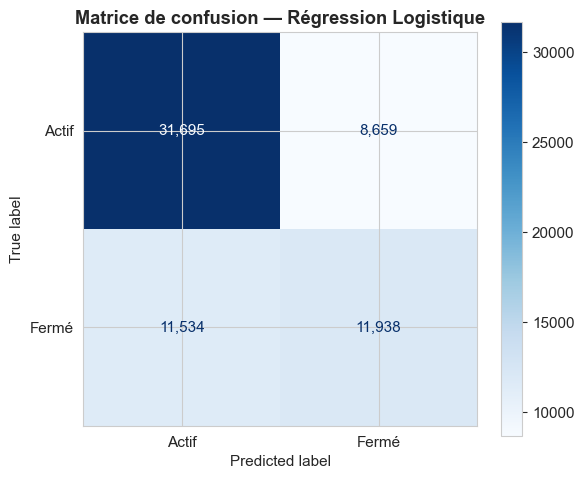

Vrais négatifs  (actifs correctement prédits)  : 31,695
Faux positifs   (actifs prédits 'fermé' à tort) : 8,659
Faux négatifs   (fermetures non détectées)      : 11,534
Vrais positifs  (fermetures correctement prédites) : 11,938


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Actif", "Fermé"])
disp.plot(ax=ax, cmap="Blues", values_format=",d")
ax.set_title("Matrice de confusion — Régression Logistique", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs  (actifs correctement prédits)  : {tn:,}")
print(f"Faux positifs   (actifs prédits 'fermé' à tort) : {fp:,}")
print(f"Faux négatifs   (fermetures non détectées)      : {fn:,}")
print(f"Vrais positifs  (fermetures correctement prédites) : {tp:,}")

### Courbe ROC et ROC-AUC

La courbe ROC (Receiver Operating Characteristic) trace le taux de vrais positifs
contre le taux de faux positifs, pour tous les seuils de décision possibles (pas
seulement 0,5) 
L'aire sous cette courbe (**AUC**, Area Under Curve) résume cette
performance en un seul chiffre entre 0,5 (pas mieux que le hasard) et 1 (parfait).

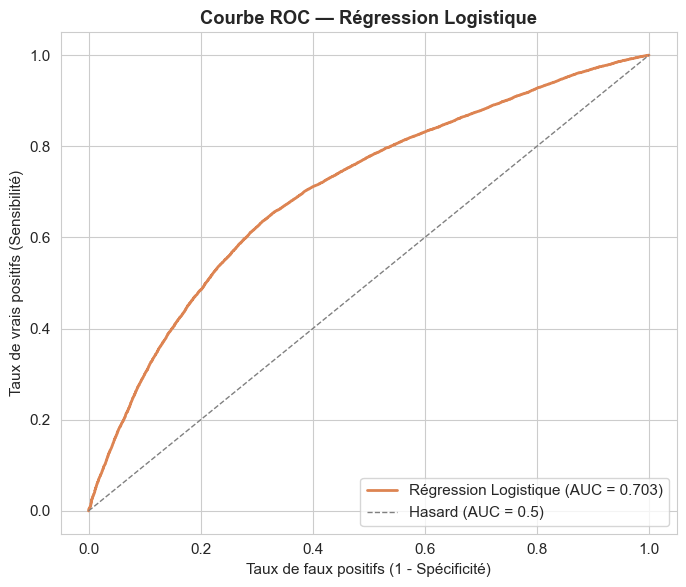

In [ ]:
fpr, tpr, seuils = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#DD8452", lw=2, label=f"Régression Logistique (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard (AUC = 0.5)")
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Sensibilité)")
plt.title("Courbe ROC — Régression Logistique", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Entraînement de plusieurs modèles de classification
 **avec et sans SMOTE** 

In [ ]:
def entrainer_evaluer(modele, X_tr, y_tr, X_te, y_te, nom_modele):
    """Entraîne un modèle, l'évalue, affiche ses métriques et sa matrice de
    confusion, et retourne un dict de résultats pour le tableau comparatif
    (section 11).
    """
    debut = time.time()
    modele.fit(X_tr, y_tr)
    temps = time.time() - debut

    y_pred = modele.predict(X_te)
    y_proba = modele.predict_proba(X_te)[:, 1] if hasattr(modele, "predict_proba") else None

    resultats = {
        "Modèle": nom_modele,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1-score": f1_score(y_te, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
        "Temps (s)": temps,
    }

    print(f"--- {nom_modele} ---")
    for k, v in resultats.items():
        if k not in ("Modèle",):
            print(f"  {k:12s} : {v:.4f}" if isinstance(v, float) else f"  {k:12s} : {v}")

    return resultats, y_pred, y_proba


resultats_tous_modeles = []  

Pour les modeles sans scaling, on reconstruit une version SMOTE non standardisee

In [40]:
from imblearn.over_sampling import SMOTE
smote_unscaled = SMOTE(random_state=RANDOM_STATE)
X_train_smote_raw, y_train_smote_raw = smote_unscaled.fit_resample(X_train, y_train)

### 10.1 K-Nearest Neighbors (KNN)
Sous-échantillon du jeu de TEST pour KNN uniquement (sensible à la taille de l'échantillion)

Grid search

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# --- Échantillon réduit pour accélérer le Grid Search ---
N_GRIDSEARCH_KNN = 10000  

X_train_sample_knn, _, y_train_sample_knn, _ = train_test_split(
    X_train_scaled, y_train,
    train_size=N_GRIDSEARCH_KNN,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print(f"Grid Search KNN sur un sous-échantillon d'entraînement de {N_GRIDSEARCH_KNN:,} comptes "
      f"(sur {len(X_train_scaled):,} disponibles).")

# --- Grid Search ---
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_knn.fit(X_train_sample_knn, y_train_sample_knn)

print("Meilleurs hyperparamètres KNN :", grid_search_knn.best_params_)
print("Meilleur score CV (f1) :", grid_search_knn.best_score_)

best_knn = grid_search_knn.best_estimator_

Grid Search KNN sur un sous-échantillon d'entraînement de 10,000 comptes (sur 255,303 disponibles).
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs hyperparamètres KNN : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Meilleur score CV (f1) : 0.49846138976136806


In [42]:
from sklearn.neighbors import KNeighborsClassifier

#Echantillion de KNN
N_TEST_KNN = 10000
X_test_scaled_knn, _, y_test_knn, _ = train_test_split(
    X_test_scaled, y_test, train_size=N_TEST_KNN, random_state=RANDOM_STATE, stratify=y_test
)
print(f"KNN évalué sur un sous-échantillon de test de {N_TEST_KNN:,} comptes "
      f"(sur {len(X_test_scaled):,} disponibles) ")

# --- Sans SMOTE ---
res, y_pred_knn, y_proba_knn = entrainer_evaluer(
    best_knn, X_train_scaled, y_train, X_test_scaled_knn, y_test_knn, "KNN (GridSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

KNN évalué sur un sous-échantillon de test de 10,000 comptes (sur 63,826 disponibles) 
--- KNN (GridSearch, sans SMOTE) ---
  Accuracy     : 0.7128
  Precision    : 0.6298
  Recall       : 0.5311
  F1-score     : 0.5763
  ROC-AUC      : 0.7501
  Temps (s)    : 0.0609


In [43]:
# --- Avec SMOTE ---
res, y_pred_knn_sm, y_proba_knn_sm = entrainer_evaluer(
    best_knn, X_train_smote, y_train_smote, X_test_scaled_knn, y_test_knn, "KNN (GridSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- KNN (GridSearch, avec SMOTE) ---
  Accuracy     : 0.6800
  Precision    : 0.5520
  Recall       : 0.6883
  F1-score     : 0.6127
  ROC-AUC      : 0.7430
  Temps (s)    : 1.2332


### 10.2 Decision Tree

Grid search

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# --- Grid Search pour Decision Tree ---
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_dt.fit(X_train, y_train)

print("Meilleurs hyperparamètres Decision Tree :", grid_search_dt.best_params_)
print("Meilleur score CV (f1) :", grid_search_dt.best_score_)

best_dt = grid_search_dt.best_estimator_

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Meilleurs hyperparamètres Decision Tree : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Meilleur score CV (f1) : 0.8771068931210232


In [45]:
#Sans smote
res, y_pred_dt, y_proba_dt = entrainer_evaluer(
    best_dt, X_train, y_train, X_test, y_test, "Arbre de Décision (GridSearch, sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (GridSearch, sans SMOTE) ---
  Accuracy     : 0.9154
  Precision    : 0.9217
  Recall       : 0.8414
  F1-score     : 0.8797
  ROC-AUC      : 0.9416
  Temps (s)    : 1.2170


In [46]:
#Avec Smote
res, y_pred_dt_sm, y_proba_dt_sm = entrainer_evaluer(
    best_dt, X_train_smote, y_train_smote, X_test, y_test, "Arbre de Décision (GridSearch, avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Arbre de Décision (GridSearch, avec SMOTE) ---
  Accuracy     : 0.3891
  Precision    : 0.3741
  Recall       : 0.9819
  F1-score     : 0.5417
  ROC-AUC      : 0.4977
  Temps (s)    : 1.7648


### 10.3 Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
res, y_pred_rf, y_proba_rf = entrainer_evaluer(
    rf, X_train, y_train, X_test, y_test, "Random Forest (sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- Random Forest (sans SMOTE) ---
  Accuracy     : 0.9166
  Precision    : 0.9235
  Recall       : 0.8430
  F1-score     : 0.8814
  ROC-AUC      : 0.9440
  Temps (s)    : 16.1460


In [48]:
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
res, y_pred_rf_sm, y_proba_rf_sm = entrainer_evaluer(
    rf_smote, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "Random Forest (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- Random Forest (avec SMOTE) ---
  Accuracy     : 0.9158
  Precision    : 0.9167
  Recall       : 0.8483
  F1-score     : 0.8812
  ROC-AUC      : 0.9437
  Temps (s)    : 24.0824


### 10.4 SVM

In [49]:
from sklearn.svm import SVC

# Sous-échantillon stratifié pour rendre l'entraînement praticable (voir note ci-dessus) :
# le SVM à noyau RBF a une complexité qui croît très rapidement avec le nombre de lignes.
n_echantillon_svm = 20000
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_scaled, y_train, train_size=n_echantillon_svm,
    random_state=RANDOM_STATE, stratify=y_train,
)
print(f"SVM entraîné sur un sous-échantillon de {n_echantillon_svm:,} comptes "
      f"(sur {len(X_train_scaled):,} disponibles)")

svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
res, y_pred_svm, y_proba_svm = entrainer_evaluer(
    svm, X_train_svm, y_train_svm, X_test_scaled, y_test, "SVM (sans SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

SVM entraîné sur un sous-échantillon de 20,000 comptes (sur 255,303 disponibles)
--- SVM (sans SMOTE, sous-échantillon) ---
  Accuracy     : 0.6910
  Precision    : 0.6000
  Recall       : 0.4789
  F1-score     : 0.5327
  ROC-AUC      : 0.7057
  Temps (s)    : 115.3842


In [50]:
smote_svm = SMOTE(random_state=RANDOM_STATE)
X_train_svm_sm, y_train_svm_sm = smote_svm.fit_resample(X_train_svm, y_train_svm)

svm_smote = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
res, y_pred_svm_sm, y_proba_svm_sm = entrainer_evaluer(
    svm_smote, X_train_svm_sm, y_train_svm_sm, X_test_scaled, y_test,
    "SVM (avec SMOTE, sous-échantillon)"
)
resultats_tous_modeles.append(res)

--- SVM (avec SMOTE, sous-échantillon) ---
  Accuracy     : 0.6691
  Precision    : 0.5399
  Recall       : 0.6777
  F1-score     : 0.6010
  ROC-AUC      : 0.7104
  Temps (s)    : 437.2185


### 10.5 XGBoost

In [51]:
X_train["INDUSTRY"].value_counts()

INDUSTRY
0.783622    200061
0.125200     31964
0.002143       547
0.001931       493
0.001739       444
             ...  
0.000106        54
0.000212        54
0.000196        50
0.000165        42
0.000004        40
Name: count, Length: 138, dtype: int64

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)
res, y_pred_xgb, y_proba_xgb = entrainer_evaluer(
    xgb, X_train, y_train, X_test, y_test, "XGBoost (sans SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (sans SMOTE) ---
  Accuracy     : 0.9168
  Precision    : 0.9223
  Recall       : 0.8448
  F1-score     : 0.8819
  ROC-AUC      : 0.9474
  Temps (s)    : 1.9733


In [ ]:
xgb_smote = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)
res, y_pred_xgb_sm, y_proba_xgb_sm = entrainer_evaluer(
    xgb_smote, X_train_smote_raw, y_train_smote_raw, X_test, y_test, "XGBoost (avec SMOTE)"
)
resultats_tous_modeles.append(res)

--- XGBoost (avec SMOTE) ---
  Accuracy     : 0.9167
  Precision    : 0.9182
  Recall       : 0.8492
  F1-score     : 0.8824
  ROC-AUC      : 0.9464
  Temps (s)    : 2.8425


In [ ]:
joblib.dump(xgb_smote, "model.pkl")

['model.pkl']

### Matrices de confusion 

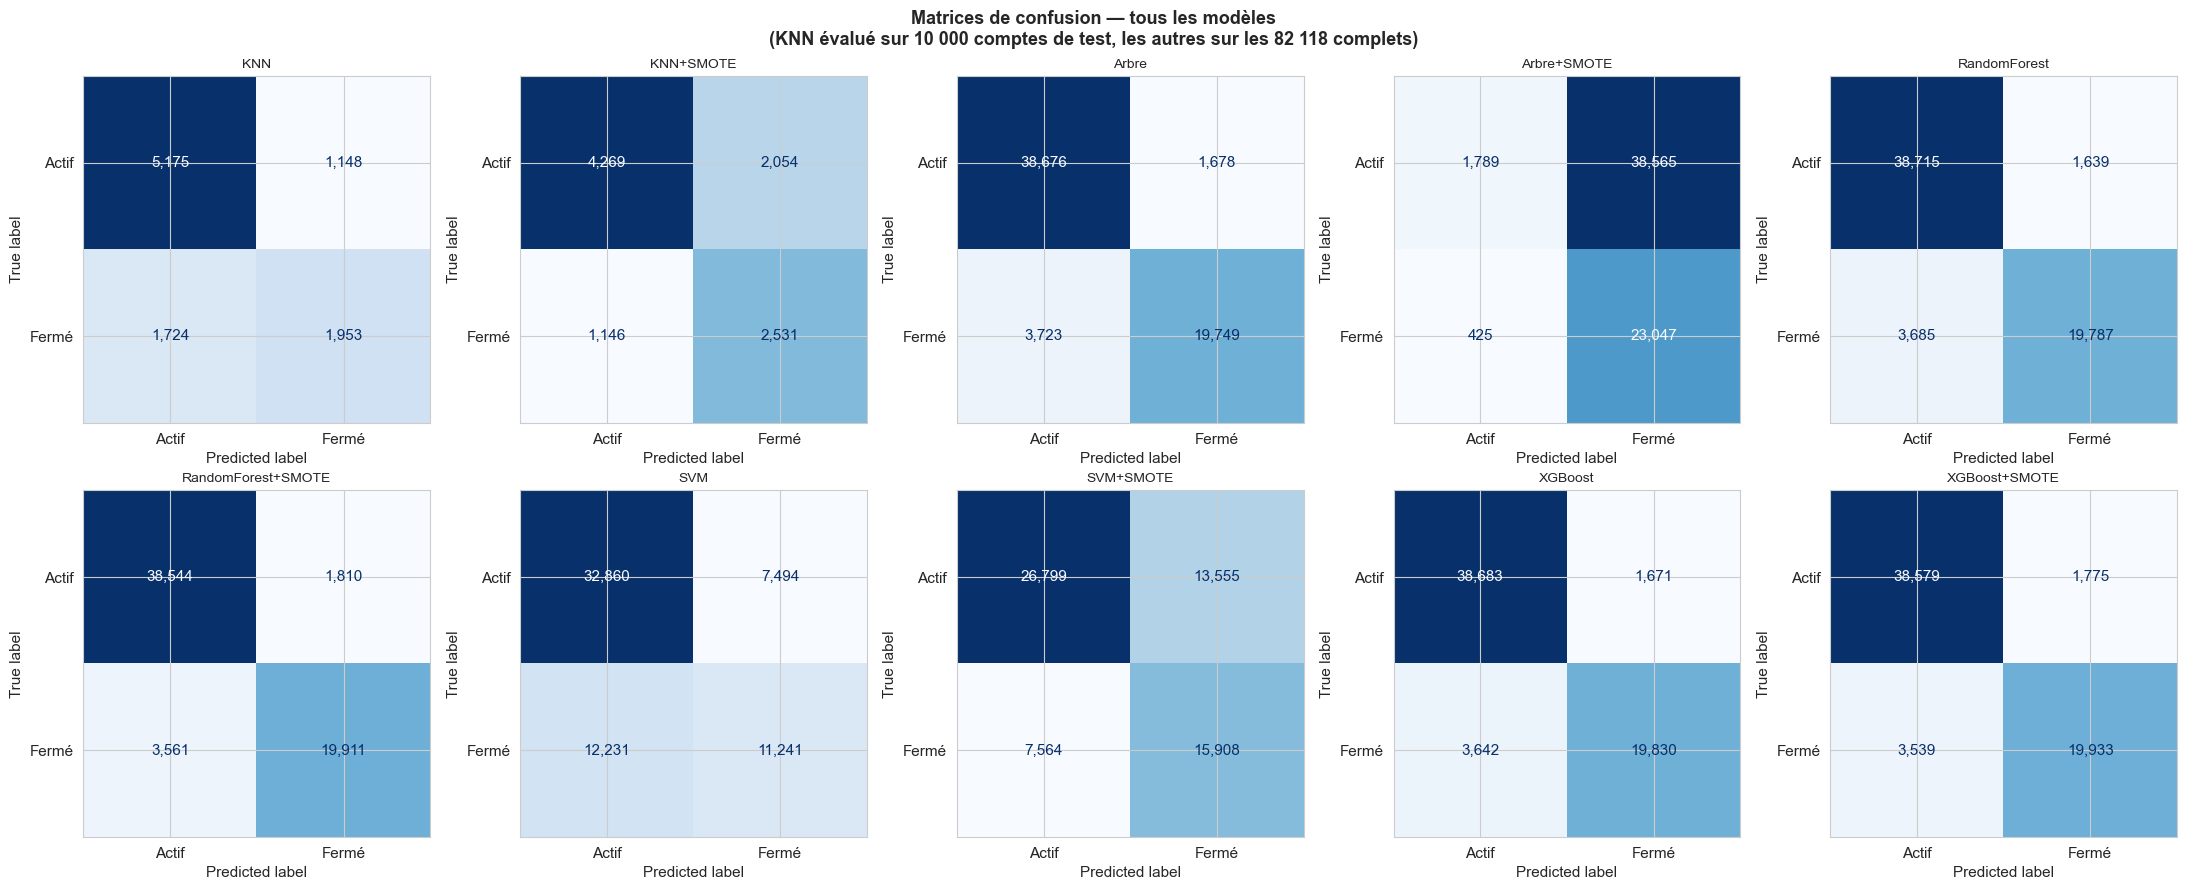

In [54]:
modeles_pred = {
    "KNN": (y_pred_knn, y_test_knn), "KNN+SMOTE": (y_pred_knn_sm, y_test_knn),
    "Arbre": (y_pred_dt, y_test), "Arbre+SMOTE": (y_pred_dt_sm, y_test),
    "RandomForest": (y_pred_rf, y_test), "RandomForest+SMOTE": (y_pred_rf_sm, y_test),
    "SVM": (y_pred_svm, y_test), "SVM+SMOTE": (y_pred_svm_sm, y_test),
    "XGBoost": (y_pred_xgb, y_test), "XGBoost+SMOTE": (y_pred_xgb_sm, y_test),
}

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, (nom, (y_p, y_t)) in enumerate(modeles_pred.items()):
    cm_i = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=["Actif", "Fermé"])
    disp.plot(ax=axes[i], cmap="Blues", values_format=",d", colorbar=False)
    axes[i].set_title(nom, fontsize=10)
plt.suptitle("Matrices de confusion — tous les modèles\n"
             "(KNN évalué sur 10 000 comptes de test, les autres sur les 82 118 complets)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Courbes ROC vue d'ensemble

Les courbes KNN ne sont pas incluses dans ce graphique 

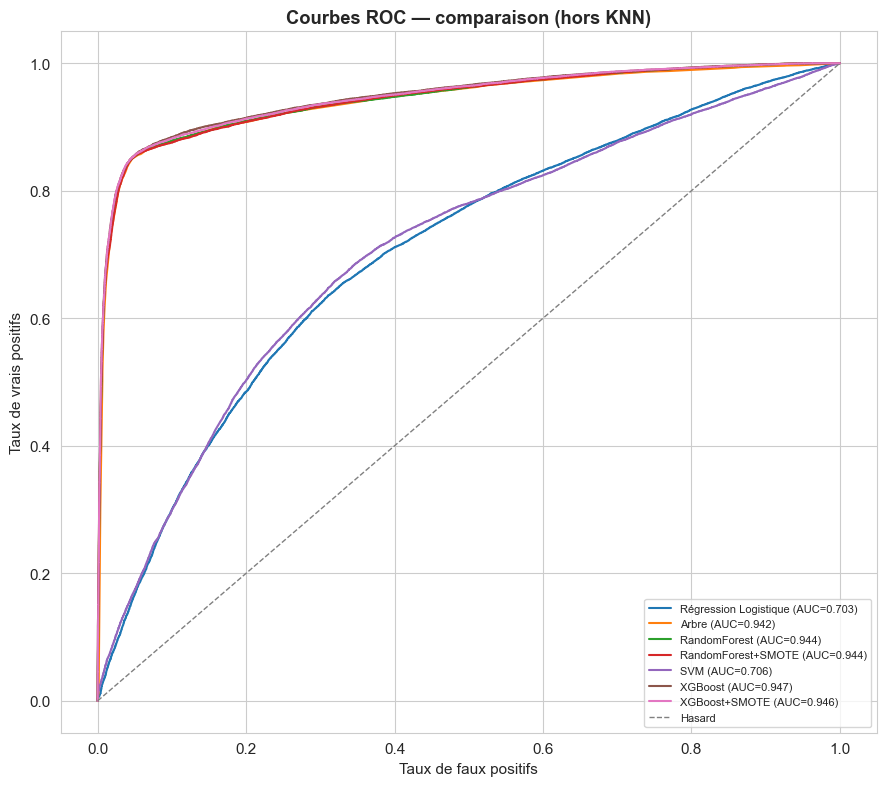

In [55]:
modeles_proba = {
    "Régression Logistique": y_proba,
    "Arbre": y_proba_dt, "RandomForest": y_proba_rf, "RandomForest+SMOTE": y_proba_rf_sm,
    "SVM": y_proba_svm, "XGBoost": y_proba_xgb, "XGBoost+SMOTE": y_proba_xgb_sm,
}

plt.figure(figsize=(9, 8))
for nom, proba in modeles_proba.items():
    if proba is not None:
        fpr_i, tpr_i, _ = roc_curve(y_test, proba)
        auc_i = roc_auc_score(y_test, proba)
        plt.plot(fpr_i, tpr_i, lw=1.5, label=f"{nom} (AUC={auc_i:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Hasard")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison (hors KNN)", fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Tableau comparatif des modèles

In [56]:
comparaison = pd.DataFrame(resultats_tous_modeles)
comparaison = comparaison.sort_values("F1-score", ascending=False).reset_index(drop=True)

# Mise en forme : pourcentages pour les métriques, secondes arrondies pour le temps
comparaison_affichage = comparaison.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    comparaison_affichage[col] = (comparaison_affichage[col] * 100).round(2).astype(str) + "%"
comparaison_affichage["Temps (s)"] = comparaison_affichage["Temps (s)"].round(2)

comparaison_affichage

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Temps (s)
0,XGBoost (avec SMOTE),91.67%,91.82%,84.92%,88.24%,94.64%,2.84
1,XGBoost (sans SMOTE),91.68%,92.23%,84.48%,88.19%,94.74%,1.97
2,Random Forest (sans SMOTE),91.66%,92.35%,84.3%,88.14%,94.4%,16.15
3,Random Forest (avec SMOTE),91.58%,91.67%,84.83%,88.12%,94.37%,24.08
4,"Arbre de Décision (GridSearch, sans SMOTE)",91.54%,92.17%,84.14%,87.97%,94.16%,1.22
5,"KNN (GridSearch, avec SMOTE)",68.0%,55.2%,68.83%,61.27%,74.3%,1.23
6,"SVM (avec SMOTE, sous-échantillon)",66.91%,53.99%,67.77%,60.1%,71.04%,437.22
7,"KNN (GridSearch, sans SMOTE)",71.28%,62.98%,53.11%,57.63%,75.01%,0.06
8,"Arbre de Décision (GridSearch, avec SMOTE)",38.91%,37.41%,98.19%,54.17%,49.77%,1.76
9,"SVM (sans SMOTE, sous-échantillon)",69.1%,60.0%,47.89%,53.27%,70.57%,115.38


In [57]:
comparaison_recall = pd.DataFrame(resultats_tous_modeles)
comparaison_recall = comparaison_recall.sort_values("Recall", ascending=False).reset_index(drop=True)

# Mise en forme : pourcentages pour les métriques, secondes arrondies pour le temps
comparaison_affichage = comparaison_recall.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    comparaison_affichage[col] = (comparaison_affichage[col] * 100).round(2).astype(str) + "%"
comparaison_affichage["Temps (s)"] = comparaison_affichage["Temps (s)"].round(2)

comparaison_affichage

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Temps (s)
0,"Arbre de Décision (GridSearch, avec SMOTE)",38.91%,37.41%,98.19%,54.17%,49.77%,1.76
1,XGBoost (avec SMOTE),91.67%,91.82%,84.92%,88.24%,94.64%,2.84
2,Random Forest (avec SMOTE),91.58%,91.67%,84.83%,88.12%,94.37%,24.08
3,XGBoost (sans SMOTE),91.68%,92.23%,84.48%,88.19%,94.74%,1.97
4,Random Forest (sans SMOTE),91.66%,92.35%,84.3%,88.14%,94.4%,16.15
5,"Arbre de Décision (GridSearch, sans SMOTE)",91.54%,92.17%,84.14%,87.97%,94.16%,1.22
6,"KNN (GridSearch, avec SMOTE)",68.0%,55.2%,68.83%,61.27%,74.3%,1.23
7,"SVM (avec SMOTE, sous-échantillon)",66.91%,53.99%,67.77%,60.1%,71.04%,437.22
8,"KNN (GridSearch, sans SMOTE)",71.28%,62.98%,53.11%,57.63%,75.01%,0.06
9,"SVM (sans SMOTE, sous-échantillon)",69.1%,60.0%,47.89%,53.27%,70.57%,115.38


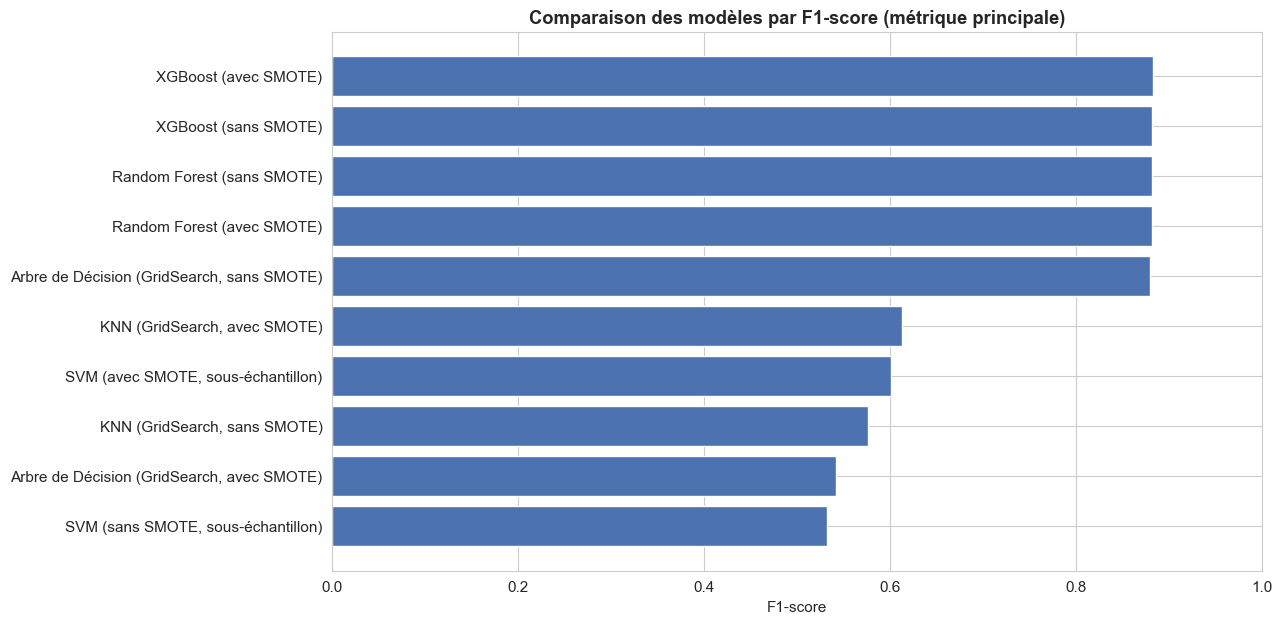

In [58]:
fig, ax = plt.subplots(figsize=(12, 7))
comparaison_tri = comparaison.sort_values("F1-score", ascending=True)
ax.barh(comparaison_tri["Modèle"], comparaison_tri["F1-score"], color="#4C72B0")
ax.set_xlabel("F1-score")
ax.set_title("Comparaison des modèles par F1-score (métrique principale)", fontweight="bold")
ax.set_xlim(0, 1)
#for i, v in enumerate(comparaison_tri["F1-score"]):
    #ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
#plt.tight_layout()
plt.show()

### Quel modèle recommander, et pourquoi ?


**Recommandation** : sur ce jeu de données, XGBoost offre le meilleur F1-score et
ROC-AUC :  c'est le candidat à retenir par défaut

## 11. Importance des variables
Pour DT, Random Forest et XGBoost pour vérifier que les décisions du modèle sont **défendables d'un point de vue métier**, pas seulement statistiquement performantes sur ce jeu de test

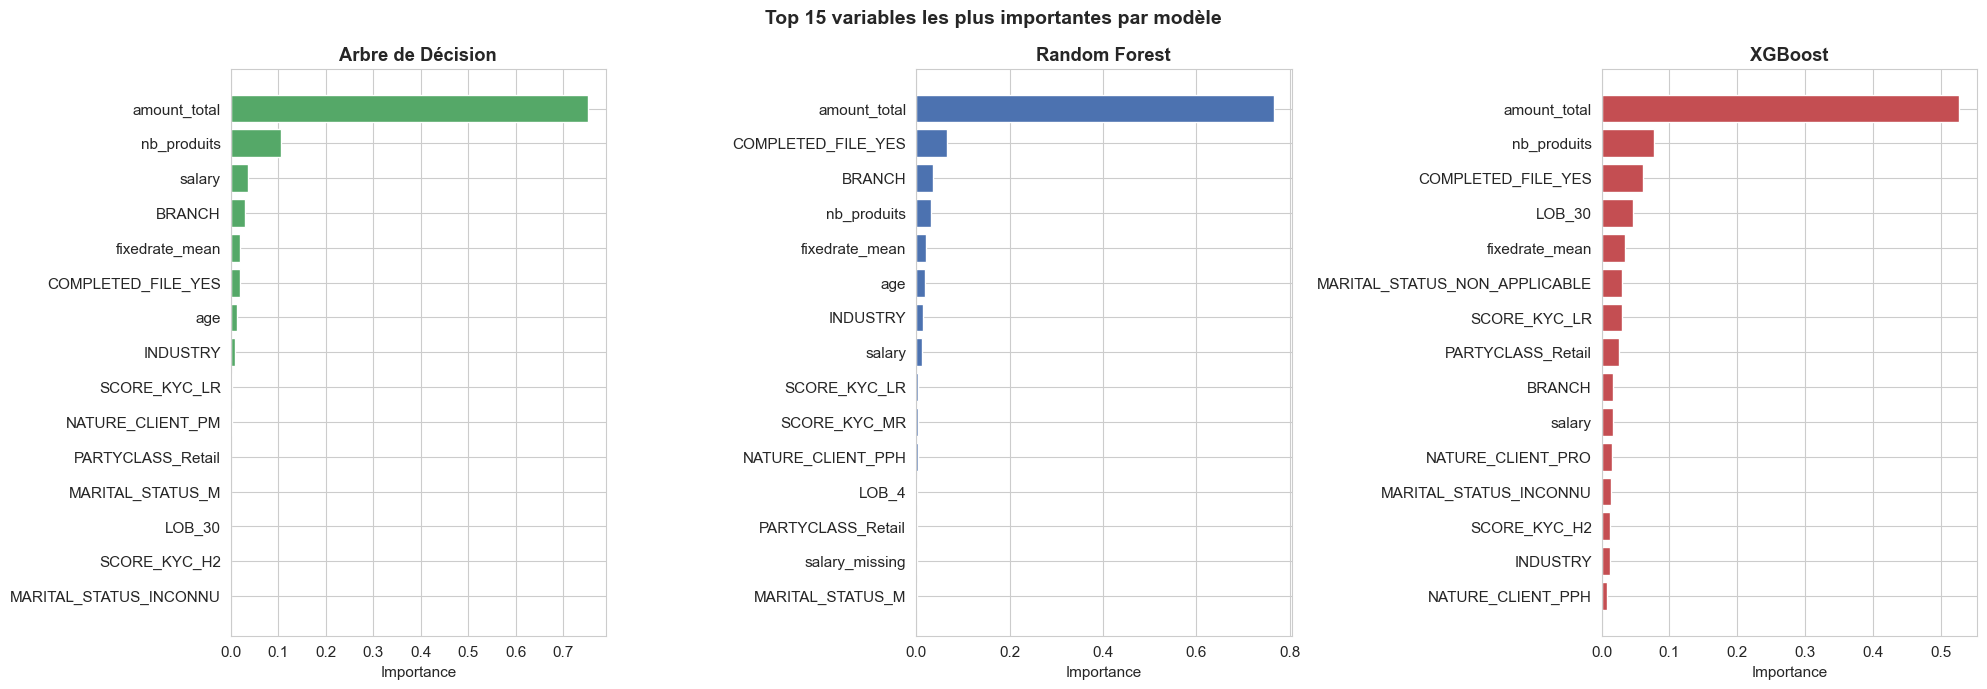

Variables les plus importantes (XGBoost, top 10) :
amount_total                     0.526627
nb_produits                      0.077169
COMPLETED_FILE_YES               0.060932
LOB_30                           0.046619
fixedrate_mean                   0.035140
MARITAL_STATUS_NON_APPLICABLE    0.030206
SCORE_KYC_LR                     0.029907
PARTYCLASS_Retail                0.026381
BRANCH                           0.017345
salary                           0.016916
dtype: float32


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Arbre de décision ---
importances_dt = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[0].barh(importances_dt.index[::-1], importances_dt.values[::-1], color="#55A868")
axes[0].set_title("Arbre de Décision", fontweight="bold")
axes[0].set_xlabel("Importance")

# --- Random Forest ---
importances_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[1].barh(importances_rf.index[::-1], importances_rf.values[::-1], color="#4C72B0")
axes[1].set_title("Random Forest", fontweight="bold")
axes[1].set_xlabel("Importance")

# --- XGBoost ---
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
axes[2].barh(importances_xgb.index[::-1], importances_xgb.values[::-1], color="#C44E52")
axes[2].set_title("XGBoost", fontweight="bold")
axes[2].set_xlabel("Importance")

plt.suptitle("Top 15 variables les plus importantes par modèle", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Variables les plus importantes (XGBoost, top 10) :")
print(importances_xgb.head(10))

## 12. Conclusion

**XGBoost (avec SMOTE)** — meilleur F1-score et ROC-AUC du comparatif, tout en
restant rapide à entraîner. 